# Time Series Analysis

Explore sales trends, seasonality, holiday effects, autocorrelation, and store-level variation in the prepared Store-Week dataset.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def find_project_root():
    path = Path.cwd().resolve()

    for candidate in [path, *path.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [4]:
store_week = pd.read_csv(
    PROCESSED_DIR / "store_week.csv"
)

store_week["Date"] = pd.to_datetime(
    store_week["Date"]
)

## Dataset Validation

In [6]:
print("Rows:", len(store_week))
print("Stores:", store_week["Store"].nunique())
print("Weeks:", store_week["Date"].nunique())
print(
    "Date range:",
    store_week["Date"].min().date(),
    "to",
    store_week["Date"].max().date()
)

Rows: 6435
Stores: 45
Weeks: 143
Date range: 2010-02-05 to 2012-10-26


In [7]:
assert not store_week.duplicated(
    ["Store", "Date"]
).any()

assert store_week["Weekly_Sales"].notna().all()

print("Store-Week grain: validated")

Store-Week grain: validated


## Overall Sales Trend

In [9]:
weekly_sales = (
    store_week
    .groupby("Date", as_index=False)["Weekly_Sales"]
    .sum()
)

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


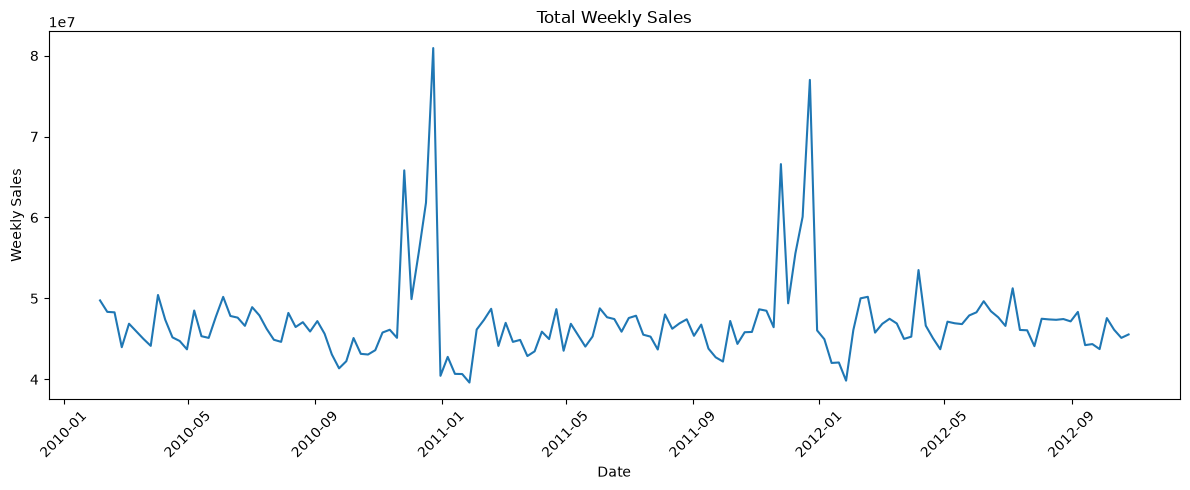

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Total Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
weekly_sales["Rolling_12W"] = (
    weekly_sales["Weekly_Sales"]
    .rolling(12)
    .mean()
)

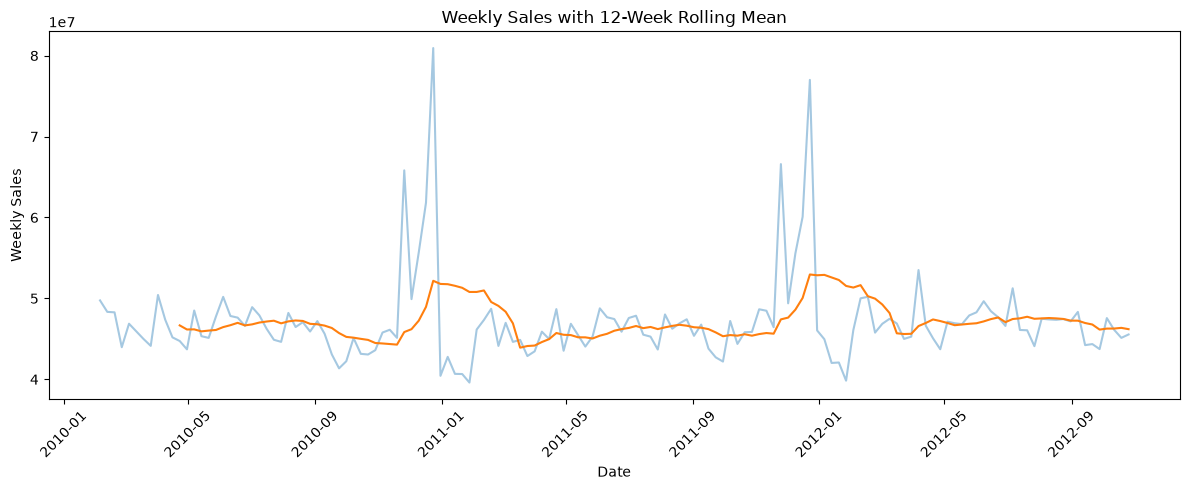

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    alpha=0.4
)

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Rolling_12W"]
)

plt.title("Weekly Sales with 12-Week Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Store-Level Variation

In [14]:
store_summary = (
    store_week
    .groupby("Store")["Weekly_Sales"]
    .agg(["sum", "mean", "std"])
    .sort_values("sum", ascending=False)
)

store_summary.head(10)

,sum,mean,std
Store,,,
20,3.013978e+08,2.107677e+06,275900.562742
4,2.995440e+08,2.094713e+06,266201.442297
14,2.889999e+08,2.020978e+06,317569.949476
13,2.865177e+08,2.003620e+06,265506.995776
2,2.753824e+08,1.925751e+06,237683.694682
10,2.716177e+08,1.899425e+06,302262.062504
27,2.538559e+08,1.775216e+06,239930.135688
6,2.237561e+08,1.564728e+06,212525.855862
1,2.224028e+08,1.555264e+06,155980.767761


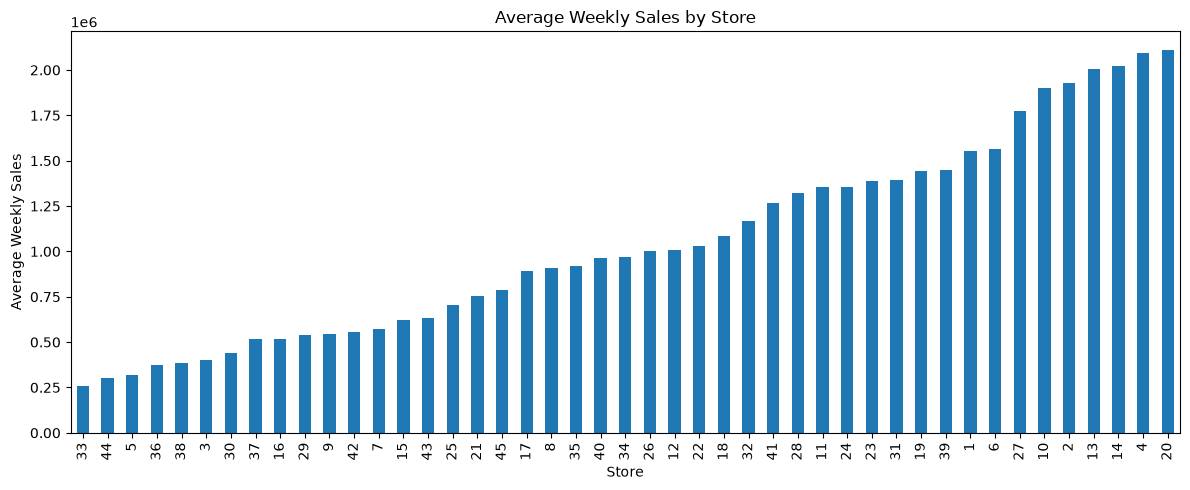

In [15]:
plt.figure(figsize=(12, 5))

store_summary["mean"].sort_values().plot(
    kind="bar"
)

plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

## Weekly Seasonality

In [17]:
store_week["WeekOfYear"] = (
    store_week["Date"].dt.isocalendar().week.astype(int)
)

seasonality = (
    store_week
    .groupby("WeekOfYear")["Weekly_Sales"]
    .mean()
)

seasonality.head()

WeekOfYear
1    9.747912e+05
2    9.188529e+05
3    9.192849e+05
4    8.826092e+05
5    1.051774e+06
Name: Weekly_Sales, dtype: float64

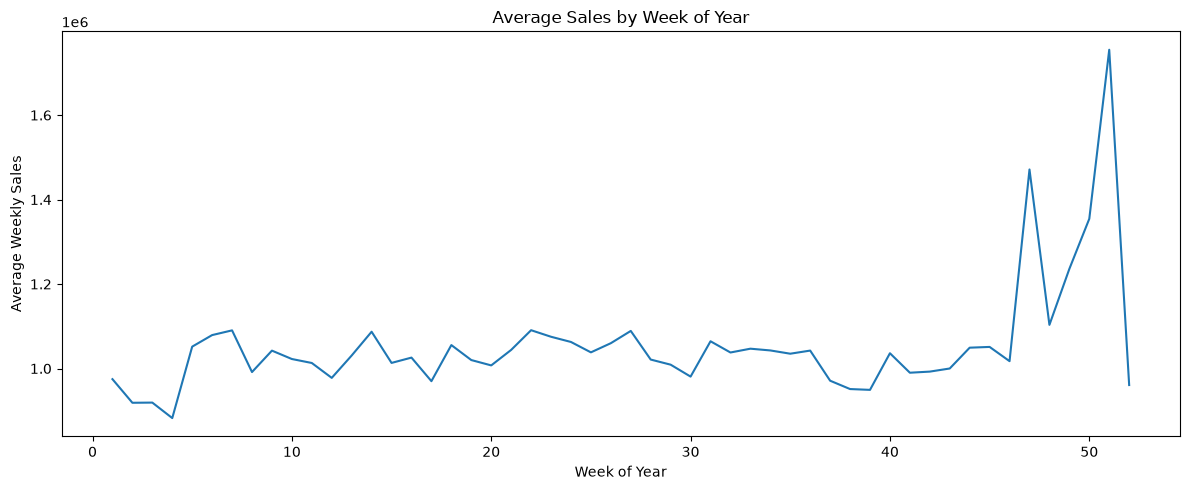

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    seasonality.index,
    seasonality.values
)

plt.title("Average Sales by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

## Monthly Pattern

In [20]:
store_week["Month"] = (
    store_week["Date"].dt.month
)

monthly_sales = (
    store_week
    .groupby("Month")["Weekly_Sales"]
    .mean()
)

monthly_sales

Month
1     9.238846e+05
2     1.053200e+06
3     1.013309e+06
4     1.026762e+06
5     1.031714e+06
6     1.064325e+06
7     1.031748e+06
8     1.048017e+06
9     9.893353e+05
10    9.996321e+05
11    1.147266e+06
12    1.281864e+06
Name: Weekly_Sales, dtype: float64

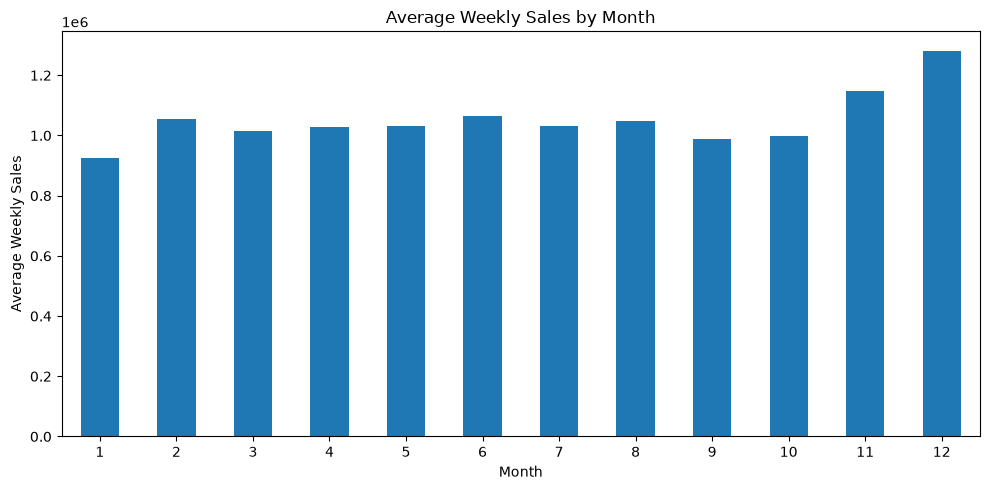

In [21]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Holiday Effect

In [23]:
holiday_sales = (
    store_week
    .groupby("IsHoliday")["Weekly_Sales"]
    .agg(["mean", "median", "count"])
)

holiday_sales

,mean,median,count
IsHoliday,,,
False,1.041256e+06,956211.20,5985
True,1.122888e+06,1018538.04,450


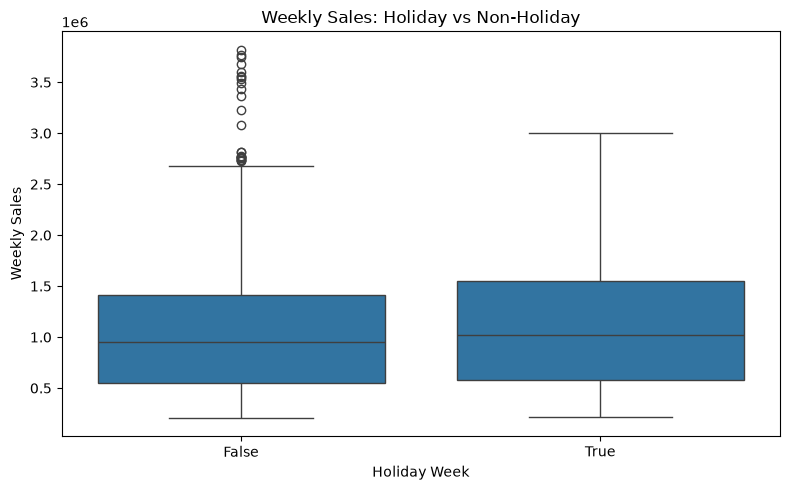

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=store_week,
    x="IsHoliday",
    y="Weekly_Sales"
)

plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Week")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

## Autocorrelation

In [26]:
autocorrelation = {
    lag: weekly_sales["Weekly_Sales"].autocorr(lag)
    for lag in [1, 2, 4, 13, 26, 52]
}

pd.Series(autocorrelation, name="Autocorrelation")

1     0.337788
2     0.221048
4     0.174437
13   -0.112862
26    0.080316
52    0.926157
Name: Autocorrelation, dtype: float64

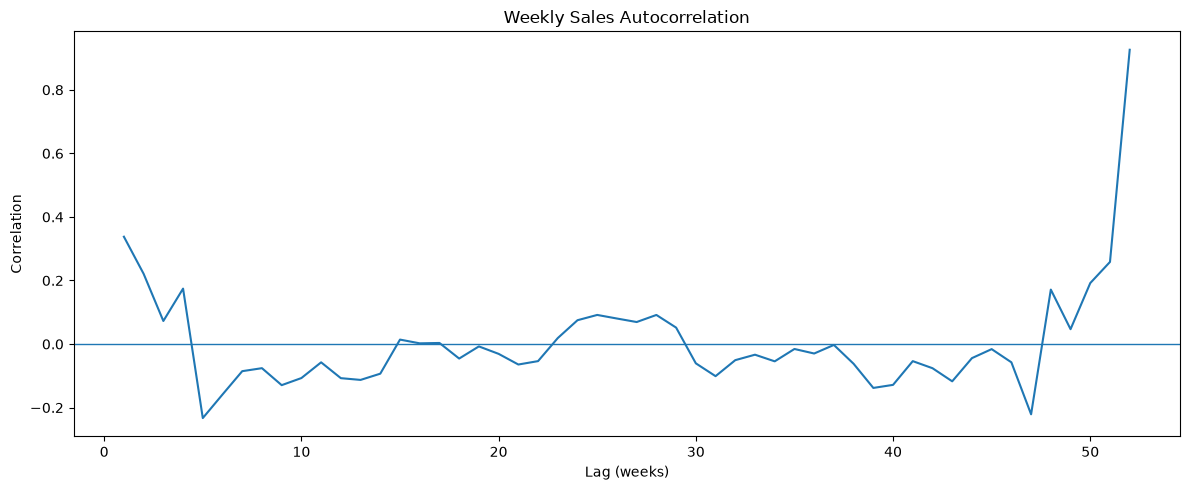

In [27]:
lags = range(1, 53)

acf_values = [
    weekly_sales["Weekly_Sales"].autocorr(lag)
    for lag in lags
]

plt.figure(figsize=(12, 5))

plt.plot(lags, acf_values)

plt.axhline(0, linewidth=1)

plt.title("Weekly Sales Autocorrelation")
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

## Store Type Comparison

In [29]:
type_summary = (
    store_week
    .groupby("Type")["Weekly_Sales"]
    .agg(["mean", "median", "std"])
)

type_summary

,mean,median,std
Type,,,
A,1.376673e+06,1370656.475,530879.287452
B,8.229950e+05,733037.320,407994.164932
C,4.726148e+05,477818.775,115618.943705


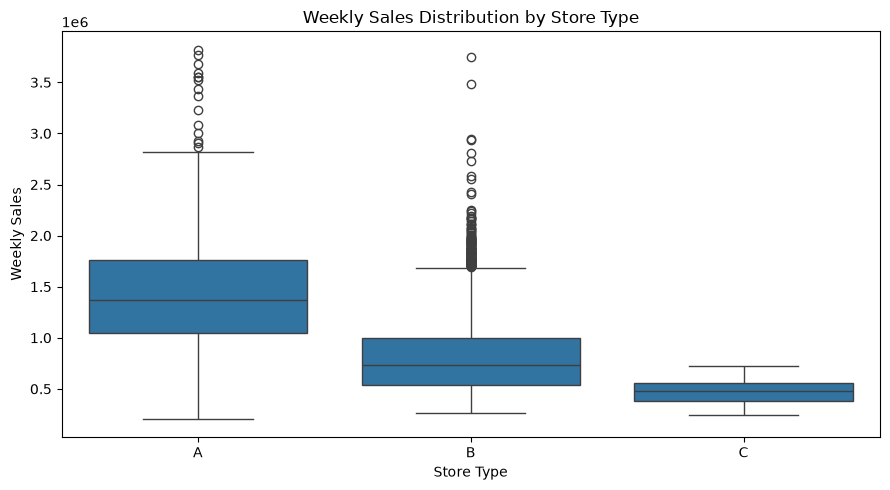

In [30]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=store_week,
    x="Type",
    y="Weekly_Sales"
)

plt.title("Weekly Sales Distribution by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

## Key Findings

- Store-level demand varies substantially across the network.
- Weekly sales show strong time-dependent and seasonal patterns.
- December records the highest average weekly sales among calendar months.
- Holiday weeks have higher average sales than non-holiday weeks.
- Sales show strong autocorrelation, particularly at the 52-week lag.
- The 52-week relationship supports year-over-year seasonal features in forecasting.
- Store Type is associated with distinct sales distributions and provides useful store-level context.